#### Learning Curve

Learning Curve is a graph that explains the relationship between the model performance vs the increasing training dataset size.

It depicts how the model performance changes as the training dataset size increases.

It helps in explaining whether

    (a.)    the model is overfitting

    (b.)    the model is underfitting

    (c.)    the model is properly fitted

    (d.)   Whether more data can improve the performance of the model.

####  1.  Problem Statement

The min objective of the problem statement is to predict whether the customer can leave the bank (churn) or not based on the telecomm customer dataset details.


####   Step 1:   Import  all the necessary libraries

In [4123]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.linear_model    import  LogisticRegression
from    sklearn.metrics         import  accuracy_score, confusion_matrix,classification_report,recall_score,precision_score,f1_score,roc_curve,roc_auc_score

#### 2: Data Collection

#### Step 2: Load the Dataset

In [4124]:
df = pd.read_csv("Telecomm_Customer.csv")

In [4125]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### OBSERVATIONS:

1.  The above dataset explains about the details of each and every customer whether it can leave the bank (churn) or not based on its details.

2.  The independent features of the dataset ranges are :---

    CustomerID........................................Total_Charges

3.  The dependent features of the dataset is "Churn".

    (a.)  If Churn is "Yes" ===================>  Customer can leave the bank

    (b.)  If Churn is "No"  ===================>  Customer cannot leave the bank

#### Step 3:  Perform the Data Exploration

In [4126]:
#### get the first five records of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4127]:
#### get the last five records of the dataset

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4128]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 7043


In [4129]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (7043, 21)


In [4130]:
#### get the columns used in the dataset

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4131]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4132]:
#### get the descriptive summary statistics about the numerical columns in the dataset

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4133]:
#### get the descriptive summary statistics about the categorical columns in the dataset

df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


#### 3. Data Cleaning

#### Step 4: Perform Feature Engineering and Data Cleaning

In [4134]:
#### To check for the NULL records used in the dataset

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [4135]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [4136]:
#### Convert the categorical values into the numerical

df.head()


X = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection', 'TechSupport'	,'StreamingTV',	'StreamingMovies',	'Contract',	'PaperlessBilling',	'PaymentMethod','Churn']

#### perform label encoding on the categorical columns

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

for x in X:
    df[x] = label.fit_transform(df[x])


In [4137]:

df['gender'].value_counts()

gender
1    3555
0    3488
Name: count, dtype: int64

In [4138]:
df['Partner'].value_counts()

Partner
0    3641
1    3402
Name: count, dtype: int64

In [4139]:
df['Dependents'].value_counts()

Dependents
0    4933
1    2110
Name: count, dtype: int64

In [4140]:
df['PhoneService'].value_counts()

PhoneService
1    6361
0     682
Name: count, dtype: int64

In [4141]:
df['MultipleLines'].value_counts()

MultipleLines
0    3390
2    2971
1     682
Name: count, dtype: int64

In [4142]:
df['InternetService'].value_counts()

InternetService
1    3096
0    2421
2    1526
Name: count, dtype: int64

In [4143]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
0    3498
2    2019
1    1526
Name: count, dtype: int64

In [4144]:
df['OnlineBackup'].value_counts()

OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64

In [4145]:
df['DeviceProtection'].value_counts()

DeviceProtection
0    3095
2    2422
1    1526
Name: count, dtype: int64

In [4146]:
df['OnlineBackup'].value_counts()

OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64

In [4147]:
df['TechSupport'].value_counts()

TechSupport
0    3473
2    2044
1    1526
Name: count, dtype: int64

In [4148]:
df['OnlineBackup'].value_counts()

OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64

In [4149]:
df['StreamingTV'].value_counts()

StreamingTV
0    2810
2    2707
1    1526
Name: count, dtype: int64

In [4150]:
df['StreamingMovies'].value_counts()

StreamingMovies
0    2785
2    2732
1    1526
Name: count, dtype: int64

In [4151]:
df['Contract'].value_counts()

Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64

In [4152]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
1    4171
0    2872
Name: count, dtype: int64

In [4153]:
df['PaymentMethod'].value_counts()

PaymentMethod
2    2365
3    1612
0    1544
1    1522
Name: count, dtype: int64

In [4154]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [4155]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [4156]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [4157]:
#### Remove the unnecessary column "customerID" from the dataset

df.drop(columns="customerID",axis=1,inplace=True)

In [4158]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


#### OBSERVATIONS:

1.  The unnecessary column "customerID" is removed from the dataset. So now the total numbers of columns has been reduced from 21 to 20.

#### Revised Dataset

In [4159]:
#### get the total length of the revised dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 7043


In [4160]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (7043, 20)


#### OBSERVATIONS:

1.  Initially the number of columns were 21 in the dataset.

2.  But there was a column named "customerID" that was not necessary. So it was removed from the dataset.

3.  Now the total number of columns are 20.

In [4161]:
#### get the columns used in the revised dataset

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4162]:
#### get the information about the revised dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


#### OBSERVATIONS:

1.  There were some categorical columns in the dataset.

2.  But after performing the feature enginerring, all the categorical columns were converted into the integer columns.

3.  Now the data is completely ready for getting trained into the machine learning model.

In [4163]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.940508,0.872923,0.790004,0.906432,0.904444,0.797104,0.985376,0.992475,0.690473,0.592219,1.574329,64.761692,2283.300441,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.948554,0.737796,0.859848,0.880162,0.879949,0.861551,0.885002,0.885091,0.833755,0.491457,1.068104,30.090047,2266.771362,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.500000,401.450000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.850000,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


#### OBSERVATIONS:

1.  The above table explains about the statistical summary for all the numerical columns used in the dataset.

In [4164]:
#### To check for the NULL records used in the dataset

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [4165]:
#### Now we see that there are 11 NULL records in "TotalCharges" column . So remove all those NULL records

df[df["TotalCharges"].isnull()]


#### Find out the mean value of the TotalCharges column and replace all the NULL Values with the mean value of it


df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [4166]:
#### To again check for the NULL records used in the dataset

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4167]:
#### To again check for the NULL records in the TotalCharges columns

df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  Initially there were 11 NULL records in TotalCharges columns in the dataset.

2.  All those NULL records in TotalCharges columns were replaced with the mean value of TotalCharges columns.

3.  Now there are no NULL records in the entire dataset.

In [4168]:
#### get the total length of the revsed dataset before deleting the duplicate records

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 7043


In [4169]:
#### get the shape of the  dataset before deleting the duplicate records

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (7043, 20)


In [4170]:
#### To check for the dupkicate records used in the dataset

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,3,45.70,45.70,1
1338,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.15,20.15,1
1491,0,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,19.55,19.55,0
1739,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.90,69.90,1
1932,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.20,20.20,0
2713,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,1,3,20.45,20.45,0
2892,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.45,20.45,0
3301,0,1,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.60,69.60,1
3754,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.05,20.05,0
4098,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,1,3,20.20,20.20,1


In [4171]:
#### Drop all the duplicate records from the dataset

df = df.drop_duplicates()

In [4172]:
#### To again check for the dupkicate records used in the dataset

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There were 22 duplicate records in the dataset.

2.  All those duplicate records were removed from the dataset.

3. There are no duplicate records present in the dataset.

In [4173]:
#### get the total length of the revised dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 7021


In [4174]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (7021, 20)


#### OBSERVATIONS:

1.  There were 7043 records along with the duplicates in the dataset.

2.  Then 22 of the dupicat records which were there in the dataset were removed.

3.  Now there are total of 7021 records in the dataset after removing the duplicates.

#### 4. Exploratory Data Analysis

#### Step 5: Perform Exploratory Data Analysis

In [4175]:
#### get the correlation for all the numerical columns used in the dataset

df.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001125,-0.001014,0.011081,0.006185,-0.006769,-0.005939,-0.001762,-0.015262,-0.012182,0.000449,-0.007045,-0.006461,-0.008781,0.000811,-0.011350,0.016304,-0.013158,0.000878,-0.008763
SeniorCitizen,-0.001125,1.000000,0.015553,-0.212115,0.015349,0.008909,0.145521,-0.031221,-0.128267,-0.013675,-0.021448,-0.151349,0.030704,0.047209,-0.143624,0.156196,-0.037320,0.219434,0.101628,0.151619
Partner,-0.001014,0.015553,1.000000,0.451659,0.377346,0.018728,0.139827,0.003667,0.150589,0.152518,0.165752,0.126422,0.136443,0.128635,0.293042,-0.015776,-0.152069,0.094301,0.316758,-0.149135
Dependents,0.011081,-0.212115,0.451659,1.000000,0.157603,-0.001092,-0.027083,0.046608,0.151984,0.090502,0.080015,0.133303,0.046140,0.020525,0.241912,-0.112220,-0.038185,-0.116191,0.062640,-0.163459
tenure,0.006185,0.015349,0.377346,0.157603,1.000000,0.009786,0.340458,-0.026847,0.325762,0.370824,0.371062,0.323197,0.288737,0.296225,0.670728,0.005053,-0.367827,0.245251,0.824164,-0.351508
PhoneService,-0.006769,0.008909,0.018728,-0.001092,0.009786,1.000000,-0.019554,0.387549,-0.015026,0.024439,0.004043,-0.018980,0.055807,0.044322,0.003101,0.016824,-0.005304,0.248984,0.114064,0.011323
MultipleLines,-0.005939,0.145521,0.139827,-0.027083,0.340458,-0.019554,1.000000,-0.106819,0.006599,0.116625,0.121633,0.010909,0.174225,0.180113,0.108553,0.164814,-0.174073,0.432246,0.451191,0.040175
InternetService,-0.001762,-0.031221,0.003667,0.046608,-0.026847,0.387549,-0.106819,1.000000,-0.029421,0.035736,0.044563,-0.027019,0.107508,0.098435,0.102456,-0.137056,0.082669,-0.320525,-0.173281,-0.047366
OnlineSecurity,-0.015262,-0.128267,0.150589,0.151984,0.325762,-0.015026,0.006599,-0.029421,1.000000,0.184211,0.175061,0.284255,0.043553,0.054847,0.374556,-0.157024,-0.096968,-0.053347,0.254298,-0.288505
OnlineBackup,-0.012182,-0.013675,0.152518,0.090502,0.370824,0.024439,0.116625,0.035736,0.184211,1.000000,0.186760,0.194841,0.146071,0.135587,0.280658,-0.012565,-0.124724,0.120391,0.375233,-0.194214


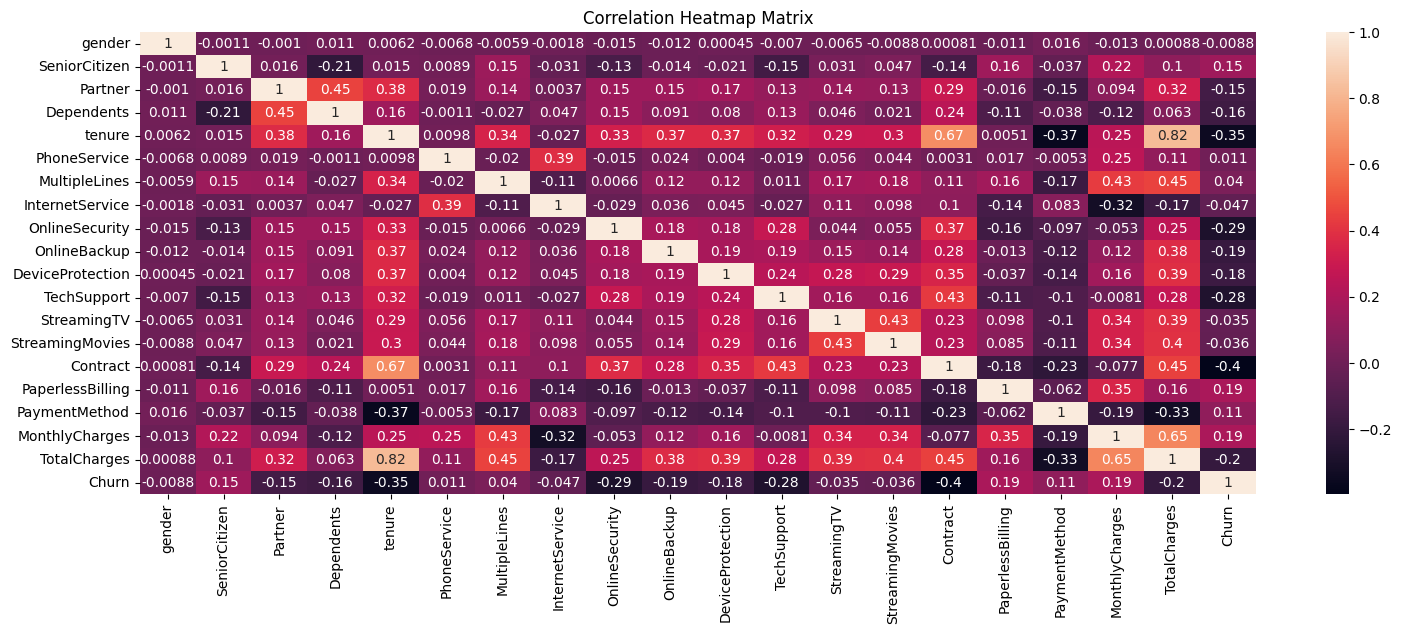

In [4176]:
#### get the graphical representation for the correlation for all the numerical columns used in the dataset


plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above matrix represents the graphical representation for the correlation between each numerical column with respect to the other in the dataset.

In [4177]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


#### 5. Feature Engineering

#### Step 6: Convert each column to their proper types in the dataset

In [4178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  

In [4179]:
#### Converting all the columns to their proper types in the dataset

df['gender']             =   df['gender'].astype('int')
df['SeniorCitizen']      =   df['SeniorCitizen'].astype('int')
df['Partner']            =   df['Partner'].astype('int')
df['Dependents']         =   df['Dependents'].astype('int')
df['tenure']             =   df['tenure'].astype('int')
df['PhoneService']       =   df['PhoneService'].astype('int')
df['MultipleLines']      =   df['MultipleLines'].astype('int')
df['InternetService']    = df['InternetService'].astype('int')
df['OnlineSecurity']     = df['OnlineSecurity'].astype('int')
df['OnlineBackup']       = df['OnlineBackup'].astype('int')
df['DeviceProtection']   = df['DeviceProtection'].astype('int')
df['TechSupport']        = df['TechSupport'].astype('int')
df['StreamingTV']        = df['StreamingTV'].astype('int')
df['StreamingMovies']    = df['StreamingMovies'].astype('int')
df['Contract']           = df['Contract'].astype('int')
df['PaperlessBilling']   = df['PaperlessBilling'].astype('int')
df['PaymentMethod']      = df['PaymentMethod'].astype('int')
df['MonthlyCharges']     = df['MonthlyCharges'].astype('int')
df['TotalCharges']       = df['TotalCharges'].astype('int')

In [4180]:
#### Again checking for the data types for each column in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            7021 non-null   int64
 1   SeniorCitizen     7021 non-null   int64
 2   Partner           7021 non-null   int64
 3   Dependents        7021 non-null   int64
 4   tenure            7021 non-null   int64
 5   PhoneService      7021 non-null   int64
 6   MultipleLines     7021 non-null   int64
 7   InternetService   7021 non-null   int64
 8   OnlineSecurity    7021 non-null   int64
 9   OnlineBackup      7021 non-null   int64
 10  DeviceProtection  7021 non-null   int64
 11  TechSupport       7021 non-null   int64
 12  StreamingTV       7021 non-null   int64
 13  StreamingMovies   7021 non-null   int64
 14  Contract          7021 non-null   int64
 15  PaperlessBilling  7021 non-null   int64
 16  PaymentMethod     7021 non-null   int64
 17  MonthlyCharges    7021 non-null   int6

#### OBSERVATIONS:

1.  All the columns have been converted to their respective data types in the dataset afetr performing the feature engineering proess.

#### Step 7: Divide the dataset into independent and dependent features

In [4181]:
#### independent features

X = df.drop(columns='Churn',axis=1)

print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [4182]:
#### dependent features

Y = df['Churn']

print(Y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7021, dtype: int64


#### 5. Train Test Split

#### Step 8: Divide the independent and dependent features into training and testing data

In [4183]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [4184]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2629,1,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0,1,70,140
2650,0,0,0,0,15,1,2,1,2,0,2,0,0,0,0,1,1,84,1302
1418,1,0,1,1,67,1,2,1,0,2,0,0,0,2,0,1,0,89,6373
5774,1,0,0,0,5,1,0,0,0,2,0,2,0,2,0,1,0,65,339
2425,1,0,0,0,26,1,0,2,1,1,1,1,1,1,0,1,2,20,511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6696,1,0,0,0,5,1,2,1,0,2,2,0,0,2,0,0,2,96,500
2094,0,0,0,0,18,1,0,2,1,1,1,1,1,1,0,0,3,19,391
4991,0,0,0,0,58,1,0,1,2,2,2,0,2,2,1,1,2,106,6145
6882,0,1,0,0,71,1,2,1,2,2,0,2,2,0,1,1,1,99,7181


In [4185]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5627,1,1,1,0,7,1,2,1,0,0,0,0,0,0,0,1,2,74,485
6126,1,1,0,0,19,1,0,1,0,0,2,0,2,2,0,1,1,95,1777
2361,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,3,45,45
2201,0,0,0,0,36,1,0,0,2,2,2,2,2,2,1,0,0,85,3003
832,0,0,1,1,70,1,0,0,2,2,2,2,0,2,1,0,1,74,5222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2310,1,0,0,0,72,0,1,0,2,2,2,2,2,2,2,1,0,63,4464
2685,0,0,1,0,72,1,2,1,2,2,2,0,2,0,2,0,0,100,7334
1104,1,0,0,0,42,1,0,2,1,1,1,1,1,1,1,1,3,19,839
5704,0,0,1,0,19,1,2,1,0,0,0,0,2,0,0,1,2,86,1564


In [4186]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (5616, 19)
Shape of the input testing  data is: (1405, 19)


In [4187]:
Y_train

2629    1
2650    0
1418    0
5774    0
2425    0
       ..
6696    0
2094    0
4991    1
6882    0
400     0
Name: Churn, Length: 5616, dtype: int64

In [4188]:
Y_test

5627    0
6126    1
2361    1
2201    0
832     0
       ..
2310    0
2685    0
1104    0
5704    0
5398    0
Name: Churn, Length: 1405, dtype: int64

In [4189]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (5616,)
Shape of the output testing  data is: (1405,)


#### OBSERVATIONS:

1.  There are a total of 7021 records in the dataset.

2.  After performing train test split function on the dataset, there are a total of 

    (a.)    5616 records ===================>  Training data

    (b.)    1405 records ===================>  Testing  data

#### 6. Model Building


#### Step 9: Perform Hyper Parameter Tuning with GridSearchCV and train the Logistic Regression Model

In [4190]:
#### define the pipeline

from    sklearn.pipeline    import  Pipeline

#### create an object for Pipeline

pipeline = Pipeline([
    ("sc"       ,       StandardScaler())               ,
    ("log"      ,       LogisticRegression())
])

In [4191]:
#### define the param grid

param_grid = {
    "log__C"        :   [0.01,  0.1,    1,  10, 100,    1000]           ,
    "log__penalty"  :   ["l1",  "l2"]                                   ,
    'log__solver'   :   ["liblinear"]    
}

####

In [4192]:
#### perform the Stratified K Fold Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4193]:
#### create an object for GridSearchCV

grid = GridSearchCV(
    pipeline                                ,
    param_grid      =       param_grid      ,
    cv              =           cv          ,
    scoring         =       'accuracy'      ,
    n_jobs          =          -1
)

In [4194]:
#### using the object of GridSearchCV, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('log', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'log__C': [0.01, 0.1, 1, 10, 100, 1000],
                         'log__penalty': ['l1', 'l2'],
                         'log__solver': ['liblinear']},
             scoring='accuracy')

In [4195]:
#### Obtain the best parameter and the estimator for the model

best_parameter = grid.best_params_

print("Best Parameters of the model is:", best_parameter)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'log__C': 0.1, 'log__penalty': 'l1', 'log__solver': 'liblinear'}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('log',
                 LogisticRegression(C=0.1, penalty='l1', solver='liblinear'))])


In [4196]:
#### Predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [4197]:
Y_pred_grid

array([1, 1, 0, ..., 0, 1, 0])

#### 7. Model Evaluation

===============================Accuracy score=======================================================
Accuracy score of the model is: 79.9288256227758
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[934  99]
 [183 189]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



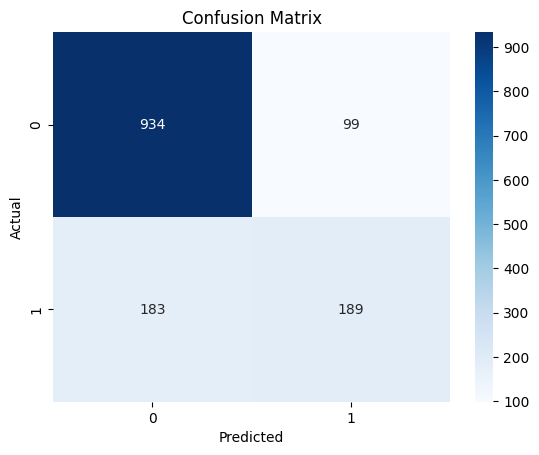

===============================Precision Score=======================================================
Precision score of the model is: 0.65625
===============================Recall Score=======================================================
Recall score of the model is: 0.5080645161290323
===============================F1 Score=======================================================
F1 score of the model is: 0.5727272727272728


In [4198]:
#### Evaluate the Classification Metrics

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)


sns.heatmap(cmgrid, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_grid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_grid)

print("Recall score of the model is:", regrid)


print("===============================F1 Score=======================================================")

f1grid = f1_score(Y_test, Y_pred_grid)

print("F1 score of the model is:", f1grid)

#### OBSERVATIONS:

1.  The accuracy score of the Logistic Regression model using Hyper Parameter Tuning with GridSerachCV is 79.92 arouns 80%

2.  The accuracy of the model is very high.

3. So the model is working fine.

In [4199]:
#### Get the predicted probabilities for each categories

Y_pred_proba = best_estimator.predict_proba(X_test)[:,1]

In [4200]:
Y_pred_proba

array([0.72357207, 0.69108241, 0.32067842, ..., 0.03538036, 0.65230112,
       0.177338  ])

#### OBSERAVTIONS:

1.  predict_proba ===============> It depicts the probabilies of each categories.

In [4201]:
#### get the roc auc score of the model

rocaucscore = roc_auc_score(Y_test, Y_pred_proba)

In [4202]:
print("ROC AUC Score of the model is:", rocaucscore)

ROC AUC Score of the model is: 0.8387708313816111


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical vaue that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.8387 explains that the model has 83.87 % of the ability to determine correctly whether the loan can be approved or not for the customer.

False Positive Rate is: [0.         0.         0.         0.00193611 0.00193611 0.00290416
 0.00290416 0.00387222 0.00387222 0.00484027 0.00484027 0.00677638
 0.00677638 0.00871249 0.00871249 0.0106486  0.0106486  0.0125847
 0.0125847  0.01355276 0.01355276 0.01452081 0.01452081 0.01548887
 0.01548887 0.01645692 0.01645692 0.01645692 0.01645692 0.01742498
 0.01742498 0.01839303 0.01839303 0.01936108 0.01936108 0.02129719
 0.02129719 0.02226525 0.02226525 0.0232333  0.0232333  0.02516941
 0.02516941 0.02710552 0.02710552 0.02807357 0.02807357 0.02807357
 0.02904163 0.02904163 0.03000968 0.03000968 0.03097773 0.03097773
 0.03291384 0.03291384 0.03291384 0.03484995 0.03484995 0.03775411
 0.03775411 0.03969022 0.03969022 0.04065828 0.04065828 0.04259439
 0.04259439 0.04356244 0.04356244 0.04453049 0.04453049 0.04549855
 0.04549855 0.0464666  0.0464666  0.04840271 0.04840271 0.04937076
 0.04937076 0.05324298 0.05324298 0.05517909 0.05517909 0.05614714
 0.05614714 0.0571152  0.0571152  0.059

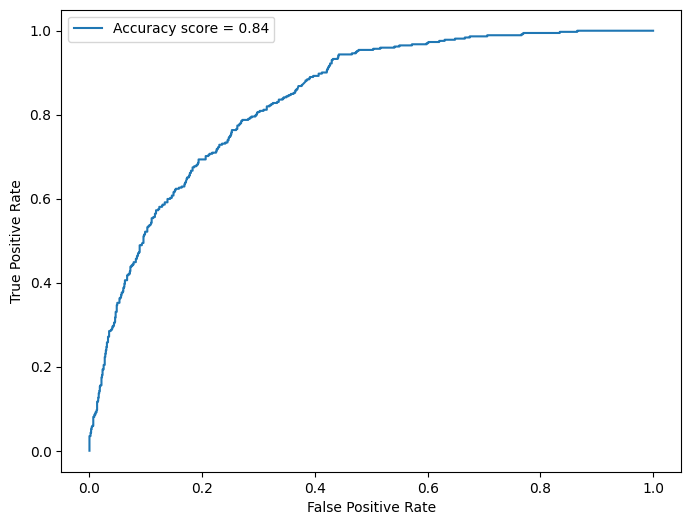

In [4203]:
#### perform the ROC Curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

print("False Positive Rate is:", fpr)

print("True Positive Rate is:", tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"Accuracy score = {rocaucscore:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### 8. Learning Curve Analysis

#### Step 10: Generate the Learning curve


Learning curve is a technique used in machine learning that explains the relationship between the model perormance vs the increasing training dataset size.

It  explains how the model performance changes with respect to the increasing training dataset size.

It also explains the model performances when trained with dierent training dataset sizes.

In [4204]:
from    sklearn.model_selection import  learning_curve


train_sizes, train_scores, validation_scores = learning_curve(
    estimator           =           best_estimator                      ,
    X                   =               X                               ,
    y                   =               Y                               ,
    cv                  =               5                               ,
    scoring             =               'accuracy'                      ,
    train_sizes         =            np.linspace(0.1,1,10)
)

In [4205]:
print("Train Sizes are:", train_sizes)

Train Sizes are: [ 561 1123 1684 2246 2808 3369 3931 4492 5054 5616]


In [4206]:
print("Training scores are:", train_scores)

Training scores are: [[0.80926916 0.80392157 0.80392157 0.80392157 0.80392157]
 [0.80765806 0.79608192 0.79608192 0.79608192 0.79608192]
 [0.81828979 0.80047506 0.79513064 0.79513064 0.79513064]
 [0.80231523 0.79252004 0.79786287 0.79786287 0.79786287]
 [0.80555556 0.7962963  0.80591168 0.80698006 0.80698006]
 [0.80647076 0.80023746 0.80914218 0.80379935 0.80379935]
 [0.8081913  0.80284915 0.80768252 0.80081404 0.80081404]
 [0.80520926 0.80409617 0.80966162 0.80298308 0.80186999]
 [0.80352196 0.80273051 0.80747922 0.80352196 0.80451128]
 [0.8048433  0.80324074 0.80858262 0.80395299 0.8034188 ]]


In [4207]:
print("Validation Scores are:", validation_scores)

Validation Scores are: [[0.79572954 0.7962963  0.78418803 0.8048433  0.8019943 ]
 [0.79430605 0.79985755 0.78205128 0.79843305 0.8034188 ]
 [0.80071174 0.79700855 0.78347578 0.79558405 0.8034188 ]
 [0.80498221 0.79985755 0.78133903 0.7977208  0.80128205]
 [0.80782918 0.80911681 0.78276353 0.79985755 0.8019943 ]
 [0.80569395 0.81267806 0.78632479 0.8019943  0.8019943 ]
 [0.80498221 0.80698006 0.78703704 0.80270655 0.8005698 ]
 [0.80640569 0.80911681 0.78347578 0.8048433  0.80769231]
 [0.80854093 0.81410256 0.78988604 0.80413105 0.80698006]
 [0.80782918 0.81410256 0.79131054 0.8048433  0.80555556]]


#### OBSERVATIONS:

1.  There are total 10 training sizes.

2.  The number of rows = Total number of training sizes = 10.

3.  So the total number of rows of the data is 10.

4.  As cv = 5, so in each row, 5 folds / scores of training data and validation data is produced.

In [4208]:
train_scores

array([[0.80926916, 0.80392157, 0.80392157, 0.80392157, 0.80392157],
       [0.80765806, 0.79608192, 0.79608192, 0.79608192, 0.79608192],
       [0.81828979, 0.80047506, 0.79513064, 0.79513064, 0.79513064],
       [0.80231523, 0.79252004, 0.79786287, 0.79786287, 0.79786287],
       [0.80555556, 0.7962963 , 0.80591168, 0.80698006, 0.80698006],
       [0.80647076, 0.80023746, 0.80914218, 0.80379935, 0.80379935],
       [0.8081913 , 0.80284915, 0.80768252, 0.80081404, 0.80081404],
       [0.80520926, 0.80409617, 0.80966162, 0.80298308, 0.80186999],
       [0.80352196, 0.80273051, 0.80747922, 0.80352196, 0.80451128],
       [0.8048433 , 0.80324074, 0.80858262, 0.80395299, 0.8034188 ]])

In [4209]:
validation_scores

array([[0.79572954, 0.7962963 , 0.78418803, 0.8048433 , 0.8019943 ],
       [0.79430605, 0.79985755, 0.78205128, 0.79843305, 0.8034188 ],
       [0.80071174, 0.79700855, 0.78347578, 0.79558405, 0.8034188 ],
       [0.80498221, 0.79985755, 0.78133903, 0.7977208 , 0.80128205],
       [0.80782918, 0.80911681, 0.78276353, 0.79985755, 0.8019943 ],
       [0.80569395, 0.81267806, 0.78632479, 0.8019943 , 0.8019943 ],
       [0.80498221, 0.80698006, 0.78703704, 0.80270655, 0.8005698 ],
       [0.80640569, 0.80911681, 0.78347578, 0.8048433 , 0.80769231],
       [0.80854093, 0.81410256, 0.78988604, 0.80413105, 0.80698006],
       [0.80782918, 0.81410256, 0.79131054, 0.8048433 , 0.80555556]])

In [4210]:
#### Compute the average accuracy across each fold of training and validation

train_mean = np.mean(train_scores, axis=1)

print(train_mean)

[0.80499109 0.79839715 0.80083135 0.79768477 0.80434473 0.80468982
 0.80407021 0.80476402 0.80435299 0.80480769]


In [4211]:
validation_mean = np.mean(validation_scores, axis=1)

print(validation_mean)

[0.79661029 0.79561335 0.79603978 0.79703633 0.80031228 0.80173708
 0.80045513 0.80230678 0.80472813 0.80472823]


#### OBSERVATIONS:

1.  It calculates the mean/average across each and every row.

2.  It is done to ensure the stability to the training and testing accuracy.

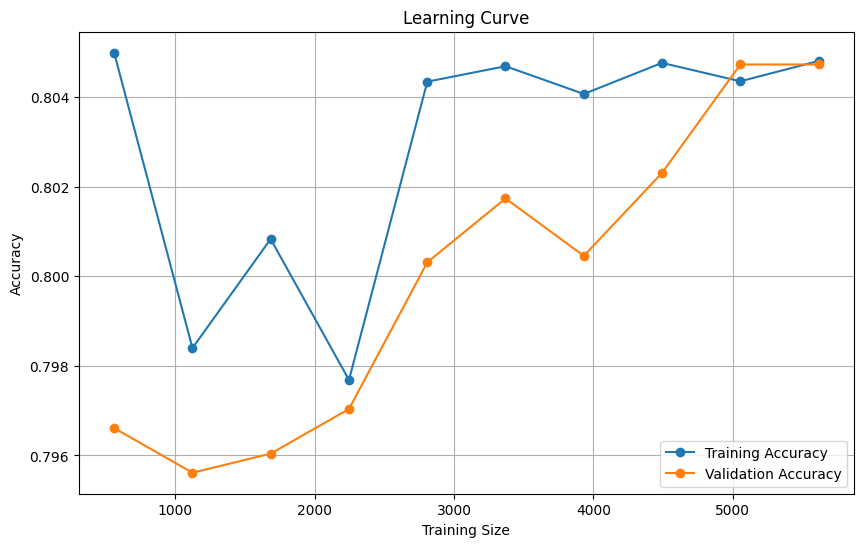

In [4212]:
#### Plot Learning Curve

plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean,     marker='o', label='Training Accuracy')

plt.plot(train_sizes, validation_mean, marker='o', label='Validation Accuracy')

plt.title("Learning Curve")

plt.xlabel("Training Size")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

#### OBSERVATIONS:

1.  With the increase in the training sizes, both the training and validation accuracy incresases.

2.  But the training accuracy is relatively higher than the validation accuracy.

#### 9. Conclusion


#### Step 11: Predict whether the loan has been approved or not or a gien sample data

In [4213]:
df.iloc[[0]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29,29,0


In [4214]:
X.iloc[[0]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29,29


In [4215]:
#### define the sample data

sample = X.iloc[[0]]

prediction = best_estimator.predict(sample)

prediction_probability = best_estimator.predict_proba(sample)

print("Prediction is:", prediction)

print("Prediction Probability is:")
print(prediction_probability)

if prediction[0] == 1:
    print("Customer is likely to leave the telecom company")
else:
    print("Customer is likely to stay with the telecom company")

Prediction is: [1]
Prediction Probability is:
[[0.47567535 0.52432465]]
Customer is likely to leave the telecom company
